In [1]:
!pip install segment-anything rasterio geopandas shapely -q

In [2]:
import os, gc, cv2, time, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T

import rasterio
import geopandas as gpd
from shapely.ops import unary_union
from shapely.validation import make_valid
from rasterio.transform import from_bounds
from shapely.geometry import Polygon, MultiPolygon


# SAM image encoder (same as training)
from segment_anything import sam_model_registry

## MODEL ARCHITECTURE

In [3]:
# ════════════════════════════════════════════════════════════════════════════
# SAM-FracTAL ResUNet
# ════════════════════════════════════════════════════════════════════════════

SAM_PIXEL_MEAN = torch.tensor([123.675, 116.280, 103.530]).view(1,3,1,1)
SAM_PIXEL_STD  = torch.tensor([ 58.395,  57.120,  57.375]).view(1,3,1,1)


class SAMFeatureExtractor(nn.Module):
    def __init__(self, sam_checkpoint: str, model_type: str = 'vit_b'):
        super().__init__()
        sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
        self.image_encoder = sam.image_encoder
        for p in self.image_encoder.parameters():
            p.requires_grad = False
        self.register_buffer('pixel_mean', SAM_PIXEL_MEAN)
        self.register_buffer('pixel_std',  SAM_PIXEL_STD)

    def forward(self, x):
        imagenet_mean = torch.tensor([0.485,0.456,0.406], device=x.device).view(1,3,1,1)
        imagenet_std  = torch.tensor([0.229,0.224,0.225], device=x.device).view(1,3,1,1)
        x_01  = x * imagenet_std + imagenet_mean
        x_sam = (x_01 * 255.0 - self.pixel_mean) / self.pixel_std
        if x_sam.shape[-1] != 1024:
            x_sam = F.interpolate(x_sam, size=(1024, 1024),
                                  mode='bilinear', align_corners=False)
        with torch.no_grad():
            feats = self.image_encoder(x_sam)
        return feats


class SAMFusion(nn.Module):
    def __init__(self, fractal_ch: int, sam_ch: int = 256, n_heads: int = 8):
        super().__init__()
        self.sam_proj   = nn.Conv2d(sam_ch, fractal_ch, 1, bias=False)
        self.norm_q     = nn.LayerNorm(fractal_ch)
        self.norm_kv    = nn.LayerNorm(fractal_ch)
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=fractal_ch, num_heads=n_heads, batch_first=True, dropout=0.0)
        self.proj_out   = nn.Sequential(
            nn.Linear(fractal_ch, fractal_ch), nn.GELU(),
            nn.Linear(fractal_ch, fractal_ch))
        self.alpha = nn.Parameter(torch.zeros(1))

    def forward(self, fractal_feat, sam_feat):
        B, C, H, W = fractal_feat.shape
        sam_proj = self.sam_proj(sam_feat)
        if sam_proj.shape[-2:] != (H, W):
            sam_proj = F.interpolate(sam_proj, size=(H, W),
                                     mode='bilinear', align_corners=False)
        q  = fractal_feat.flatten(2).permute(0, 2, 1)
        kv = sam_proj.flatten(2).permute(0, 2, 1)
        q  = self.norm_q(q);  kv = self.norm_kv(kv)
        attended, _ = self.cross_attn(q, kv, kv)
        attended    = self.proj_out(attended)
        attended    = attended.permute(0, 2, 1).view(B, C, H, W)
        return fractal_feat + torch.tanh(self.alpha) * attended


class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(channels, max(channels//reduction, 4)), nn.ReLU(),
            nn.Linear(max(channels//reduction, 4), channels), nn.Sigmoid())
    def forward(self, x):
        return x * self.fc(x).view(x.size(0), x.size(1), 1, 1)


class SpatialAttention(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 1)
        self.sig  = nn.Sigmoid()
    def forward(self, x):
        return x * self.sig(self.conv(x))


class FracTALUnit(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.ch_att = ChannelAttention(channels)
        self.sp_att = SpatialAttention(channels)
        self.alpha  = nn.Parameter(torch.tensor(0.5))
    def forward(self, x):
        a = torch.clamp(self.alpha, 0.0, 1.0)
        return a * self.ch_att(x) + (1-a) * self.sp_att(x)


class FracTALResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dilation=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.BatchNorm2d(in_ch), nn.ReLU(inplace=True),
            nn.Conv2d(in_ch, out_ch, 3, padding=dilation, dilation=dilation, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=dilation, dilation=dilation, bias=False))
        self.fractal = FracTALUnit(out_ch)
        self.proj    = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
    def forward(self, x):
        return self.proj(x) + self.fractal(self.conv(x))


class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch, n_blocks=2, dilation=1):
        super().__init__()
        blocks = [FracTALResBlock(in_ch, out_ch, dilation)]
        for _ in range(n_blocks-1):
            blocks.append(FracTALResBlock(out_ch, out_ch, dilation))
        self.blocks = nn.Sequential(*blocks)
        self.pool   = nn.MaxPool2d(2)
    def forward(self, x):
        skip = self.blocks(x)
        return self.pool(skip), skip


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up    = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.block = FracTALResBlock(out_ch + skip_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        return self.block(torch.cat([x, skip], dim=1))


class SAMFracTALResUNet(nn.Module):
    def __init__(self, sam_checkpoint, sam_model_type='vit_b', num_classes=2, base_ch=32):
        super().__init__()
        c = base_ch
        self.sam_encoder = SAMFeatureExtractor(sam_checkpoint, sam_model_type)
        self.enc1       = EncoderBlock(3,   c,    n_blocks=2)
        self.enc2       = EncoderBlock(c,   c*2,  n_blocks=2)
        self.enc3       = EncoderBlock(c*2, c*4,  n_blocks=3)
        self.enc4       = EncoderBlock(c*4, c*8,  n_blocks=3)
        self.bottleneck = nn.Sequential(
            FracTALResBlock(c*8,  c*16, dilation=2),
            FracTALResBlock(c*16, c*16, dilation=4),
            FracTALResBlock(c*16, c*16, dilation=2))
        self.sam_fusion = SAMFusion(fractal_ch=c*16, sam_ch=256, n_heads=8)
        self.dec4 = DecoderBlock(c*16, c*8,  c*8)
        self.dec3 = DecoderBlock(c*8,  c*4,  c*4)
        self.dec2 = DecoderBlock(c*4,  c*2,  c*2)
        self.dec1 = DecoderBlock(c*2,  c,    c)
        self.seg_head   = nn.Conv2d(c, num_classes, 1)
        self.bound_head = nn.Conv2d(c, 1, 1)
        self.dist_head  = nn.Conv2d(c, 1, 1)

    def forward(self, x):
        sam_feats = self.sam_encoder(x)
        x, s1 = self.enc1(x)
        x, s2 = self.enc2(x)
        x, s3 = self.enc3(x)
        x, s4 = self.enc4(x)
        x     = self.bottleneck(x)
        x     = self.sam_fusion(x, sam_feats)
        x = self.dec4(x, s4); x = self.dec3(x, s3)
        x = self.dec2(x, s2); x = self.dec1(x, s1)
        return {'seg': self.seg_head(x),
                'bound': self.bound_head(x),
                'dist': self.dist_head(x)}

    def load_trainable_state_dict(self, state_dict):
        missing, _ = self.load_state_dict(state_dict, strict=False)
        non_sam_missing = [k for k in missing if not k.startswith('sam_encoder')]
        if non_sam_missing:
            print(f'  ⚠ Missing keys: {non_sam_missing}')
        return self

In [5]:
# ════════════════════════════════════════════════════════════════════════════
# Loading Model (SAM)
# ════════════════════════════════════════════════════════════════════════════

SAM_CHECKPOINT   = '/content/drive/MyDrive/AGRI/TreeCrown_Segmentation/models/segmentation/sam_vit_b_01ec64.pth'
SAM_MODEL_TYPE   = 'vit_b'
MODEL_CHECKPOINT = '/content/drive/MyDrive/AGRI/CropField_Segmentation/result/sam-fractal-resunet-512-v02/best.pt'
OUTPUT_DIR       = '/content/drive/MyDrive/AGRI/CropField_Segmentation/output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

# Load trainable weights (FracTAL + SAMFusion only — SAM ViT loaded via checkpoint)
state_dict  = torch.load(MODEL_CHECKPOINT, map_location='cpu')
NUM_CLASSES = state_dict['seg_head.weight'].shape[0]
BASE_CH     = state_dict['seg_head.weight'].shape[1]
print(f'Checkpoint → NUM_CLASSES={NUM_CLASSES}  base_ch={BASE_CH}')

model = SAMFracTALResUNet(
    sam_checkpoint = SAM_CHECKPOINT,
    sam_model_type = SAM_MODEL_TYPE,
    num_classes    = NUM_CLASSES,
    base_ch        = BASE_CH,
).to(DEVICE)

model.load_trainable_state_dict(state_dict)
model.eval()
if DEVICE.type == 'cuda':
    model = model.half()   # FP16 — halves VRAM, same output quality

alpha_val = float(torch.tanh(model.sam_fusion.alpha).item())
print(f'SAM fusion gate  α = {alpha_val:.4f}')
print(f'Trainable params : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Device: cpu
Checkpoint → NUM_CLASSES=2  base_ch=32
SAM fusion gate  α = 0.0123
Trainable params : 23,584,404


In [6]:
# ════════════════════════════════════════════════════════════════════════════
# Inference Configuration
# ════════════════════════════════════════════════════════════════════════════

CONFIG = {
    # ── Tiling ────────────────────────────────────────────────────────────
    'tile_size'      : 512,   # match training IMG_SIZE
    'overlap'        : 128,   # tile overlap in px

    # ── Boundary cutting ──────────────────────────────────────────────────
    'bound_thresh'   : 0.50,  # higher = thinner boundaries

    # ── Polygon extraction ────────────────────────────────────────────────
    'min_field_px'   : 300,   # minimum number of field pixels
    'smooth_epsilon' : 1.5,   # Douglas-Peucker simplification tolerance

    # ── Dynamic buffering ─────────────────────────────────────────────────
    # Buffer each polygon by a fraction of its own sqrt(area) so the
    # expansion is proportional to field size — scale-invariant.
    'buffer_fraction': 0.04,  # 4% of sqrt(area)
    'buffer_min_px'  : 2,
    'buffer_max_px'  : 12,

    # ── Overlap resolution ────────────────────────────────────────────────
    'nms_iou_thresh' : 0.40,  # suppress duplicate polygons above this IoU

    # ── Output ────────────────────────────────────────────────────────────
    'output_dir'     : OUTPUT_DIR,
    'image_name'     : 'cropfield_sam_fractal',
}

In [7]:
PREPROCESS = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])


def _hann_window(size: int) -> np.ndarray:
    """2-D raised cosine window — values peak at 1.0 in the centre, 0 at edges."""
    w1d = np.hanning(size).astype(np.float32)
    return np.outer(w1d, w1d)


def run_tiled_inference(img_pil: Image.Image, model, config: dict):
    """
    SAM-FracTAL

    Returns three full-resolution numpy arrays (values in [0,1] / class ids):
      seg_map   (H, W)       — argmax class per pixel after boundary cut
      bound_map (H, W)       — boundary probability [0,1]
      dist_map  (H, W)       — distance-to-boundary probability [0,1]
    """
    tile_sz  = config['tile_size']
    overlap  = config['overlap']
    stride   = tile_sz - overlap
    thresh   = config['bound_thresh']

    W, H     = img_pil.size
    img_np   = np.array(img_pil)                    # (H, W, 3)  uint8

    # Accumulators for blended probability maps
    seg_acc   = np.zeros((H, W, 2),  dtype=np.float32)  # 2-class softmax
    bound_acc = np.zeros((H, W),     dtype=np.float32)
    dist_acc  = np.zeros((H, W),     dtype=np.float32)
    weight    = np.zeros((H, W),     dtype=np.float32)
    win       = _hann_window(tile_sz)

    # Generate tile top-left corners
    ys = list(range(0, max(H - tile_sz, 0) + 1, stride)) or [0]
    xs = list(range(0, max(W - tile_sz, 0) + 1, stride)) or [0]
    if ys[-1] + tile_sz < H: ys.append(H - tile_sz)
    if xs[-1] + tile_sz < W: xs.append(W - tile_sz)
    tiles = [(y, x) for y in ys for x in xs]

    dtype = torch.float16 if next(model.parameters()).dtype == torch.float16 else torch.float32

    for y0, x0 in tqdm(tiles, desc='Tiled inference'):
        y1, x1 = min(y0 + tile_sz, H), min(x0 + tile_sz, W)
        # Pad tile to tile_sz × tile_sz if at image edge
        patch = img_np[y0:y1, x0:x1]
        pad_b = tile_sz - (y1 - y0)
        pad_r = tile_sz - (x1 - x0)
        if pad_b > 0 or pad_r > 0:
            patch = np.pad(patch, ((0, pad_b), (0, pad_r), (0, 0)), mode='reflect')

        inp = PREPROCESS(Image.fromarray(patch)).unsqueeze(0).to(DEVICE).to(dtype)

        with torch.no_grad():
            out = model(inp)

        seg_p   = torch.softmax(out['seg'],   dim=1).squeeze(0).float().cpu().numpy()
        bound_p = torch.sigmoid(out['bound']).squeeze().float().cpu().numpy()
        dist_p  = torch.sigmoid(out['dist']).squeeze().float().cpu().numpy()

        # Unpad back to actual tile region
        rh, rw  = y1 - y0, x1 - x0
        seg_p   = seg_p[:,  :rh, :rw]
        bound_p = bound_p[  :rh, :rw]
        dist_p  = dist_p[   :rh, :rw]
        w_crop  = win[:rh, :rw]

        seg_acc  [y0:y1, x0:x1] += seg_p.transpose(1, 2, 0) * w_crop[..., None]
        bound_acc[y0:y1, x0:x1] += bound_p * w_crop
        dist_acc [y0:y1, x0:x1] += dist_p  * w_crop
        weight   [y0:y1, x0:x1] += w_crop

    # Normalise by accumulated weights
    w = np.maximum(weight, 1e-6)[..., None]
    seg_acc   /= w
    bound_acc /= np.maximum(weight, 1e-6)
    dist_acc  /= np.maximum(weight, 1e-6)

    # Apply boundary cut to segmentation
    hard_bound   = (bound_acc > thresh).astype(np.uint8)
    seg_map      = seg_acc.argmax(axis=2).astype(np.uint8)
    seg_map[hard_bound == 1] = 0

    print(f'  Boundary coverage : {hard_bound.mean()*100:.1f}%  (thresh={thresh})')
    print(f'  Field pixels      : {(seg_map>0).sum():,}  ({100*(seg_map>0).mean():.1f}%)')
    return seg_map, bound_acc, dist_acc

In [8]:
# ════════════════════════════════════════════════════════════════════════════
# Post-processing: mask → polygons → dynamic buffer → overlap resolution
# ════════════════════════════════════════════════════════════════════════════

def extract_polygons(seg_map: np.ndarray, config: dict) -> list[dict]:
    """
    Connected-component labelling → contour extraction → Douglas-Peucker
    simplification.  Returns list of dicts with keys:
      polygon  (list of (x,y) pixel coords)
      area_px  (int)
      bbox     (x,y,w,h)
    """
    field_mask = (seg_map > 0).astype(np.uint8)
    num_labels, labels = cv2.connectedComponents(field_mask)
    min_px   = config['min_field_px']
    epsilon  = config['smooth_epsilon']
    polys    = []

    for label_id in range(1, num_labels):
        component = (labels == label_id).astype(np.uint8)
        area      = int(component.sum())
        if area < min_px:
            continue
        contours, _ = cv2.findContours(component, cv2.RETR_EXTERNAL,
                                        cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue
        cnt = max(contours, key=cv2.contourArea)
        # Douglas-Peucker simplification
        approx = cv2.approxPolyDP(cnt, epsilon, closed=True)
        if len(approx) < 4:
            continue
        pts = approx.squeeze().tolist()
        if len(pts) < 4:
            continue
        x,y,w,h = cv2.boundingRect(cnt)
        polys.append({'polygon': pts, 'area_px': area, 'bbox': (x,y,w,h)})

    print(f'  Extracted {len(polys)} raw polygons  (min_px={min_px})')
    return polys


def dynamic_buffer(polys: list[dict], config: dict) -> list[dict]:
    """
    Expand each polygon by a fraction of its own sqrt(area) — scale-invariant.

    buffer_distance = clip(sqrt(area) * fraction, min_px, max_px)

    Small fields get a small absolute expansion; large fields get proportionally
    the same but capped so they never bleed into neighbours.

    join_style=2 (mitre) preserves sharp field corners rather than rounding them.
    """
    fraction = config['buffer_fraction']
    buf_min  = config['buffer_min_px']
    buf_max  = config['buffer_max_px']
    buffered = []

    for det in polys:
        pts  = det['polygon']
        geom = Polygon(pts)
        if not geom.is_valid:
            geom = make_valid(geom)
        if geom.is_empty:
            buffered.append(det)
            continue

        buf_dist = float(np.clip(geom.area**0.5 * fraction, buf_min, buf_max))
        expanded = geom.buffer(buf_dist, join_style=2)   # mitre = sharp corners

        # If buffer produces MultiPolygon take the largest piece
        if isinstance(expanded, MultiPolygon):
            expanded = max(expanded.geoms, key=lambda g: g.area)
        if expanded.is_empty or not expanded.is_valid:
            buffered.append(det)
            continue

        buffered.append({
            **det,
            'polygon' : list(expanded.exterior.coords),
            'area_px' : int(expanded.area),
            'buf_dist': round(buf_dist, 2),
        })

    buf_dists = [d.get('buf_dist', 0) for d in buffered]
    print(f'  Dynamic buffer applied: '
          f'min={min(buf_dists):.1f}px  '
          f'mean={np.mean(buf_dists):.1f}px  '
          f'max={max(buf_dists):.1f}px')
    return buffered


def resolve_overlaps(polys: list[dict]) -> list[dict]:
    geoms  = []
    for det in polys:
        g = Polygon(det['polygon'])
        if not g.is_valid:
            g = make_valid(g)
        geoms.append(g)

    # Sort by area descending — large fields get priority
    order  = sorted(range(len(geoms)), key=lambda i: geoms[i].area, reverse=True)
    canvas = [None] * len(geoms)
    claimed = []   # union of all already-placed polygons

    for i in order:
        g = geoms[i]
        if claimed:
            try:
                g = g.difference(unary_union(claimed))
            except Exception:
                pass
        if isinstance(g, MultiPolygon):
            g = max(g.geoms, key=lambda x: x.area)
        if g.is_empty or g.area < 50:
            canvas[i] = None
        else:
            canvas[i] = g
            claimed.append(g)

    resolved = []
    for i, (det, g) in enumerate(zip(polys, canvas)):
        if g is None or g.is_empty:
            continue
        resolved.append({**det,
                         'polygon': list(g.exterior.coords),
                         'area_px': int(g.area)})

    print(f'  Overlap resolution: {len(polys)} → {len(resolved)} polygons')
    return resolved


def polygon_nms(polys: list[dict], iou_thresh: float) -> list[dict]:

    if not polys:
        return polys
    polys_sorted = sorted(polys, key=lambda d: d['area_px'], reverse=True)
    keep = []
    for det in polys_sorted:
        g1 = Polygon(det['polygon'])
        if not g1.is_valid:
            g1 = make_valid(g1)
        dominated = False
        for kept in keep:
            g2 = Polygon(kept['polygon'])
            if not g2.is_valid:
                g2 = make_valid(g2)
            try:
                inter = g1.intersection(g2).area
                union = g1.union(g2).area
                iou   = inter / (union + 1e-6)
            except Exception:
                iou = 0.0
            if iou > iou_thresh:
                dominated = True
                break
        if not dominated:
            keep.append(det)
    print(f'  NMS: {len(polys)} → {len(keep)} (IoU>{iou_thresh})')
    return keep

  def polygons_to_geodataframe(polys: list[dict], image_path: str,
                              img_w: int, img_h: int) -> gpd.GeoDataFrame:
    """
    Convert pixel-coordinate polygons to a GeoDataFrame.
    Uses rasterio to read the image's geotransform and CRS.
    Falls back to pixel CRS if the image is not georeferenced.
    """
    try:
        with rasterio.open(image_path) as src:
            transform = src.transform
            crs       = src.crs
            georef    = (crs is not None and
                         transform != rasterio.transform.identity(img_h, img_w))
    except Exception:
        georef    = False
        transform = rasterio.transform.from_bounds(0, img_h, img_w, 0, img_w, img_h)
        crs       = None

    if not georef:
        print('  ⚠ Image has no geotransform — polygons in pixel coordinates')

    shapes = []
    attrs  = []
    for i, det in enumerate(polys):
        pts_px = det['polygon']
        if georef:
            # Transform pixel (col, row) → CRS coordinates
            pts_geo = [transform * (float(x), float(y)) for x, y in pts_px]
        else:
            pts_geo = [(float(x), float(y)) for x, y in pts_px]

        g = Polygon(pts_geo)
        if not g.is_valid:
            g = make_valid(g)
        if g.is_empty:
            continue
        shapes.append(g)
        attrs.append({
            'field_id' : i + 1,
            'area_px'  : det['area_px'],
            'buf_dist' : det.get('buf_dist', 0.0),
        })

    gdf = gpd.GeoDataFrame(attrs, geometry=shapes,
                            crs=crs if georef else 'EPSG:4326')
    print(f'  GeoDataFrame: {len(gdf)} fields  |  CRS={gdf.crs}')
    return gdf

In [10]:
# ════════════════════════════════════════════════════════════════════════════
# Visualization
# ════════════════════════════════════════════════════════════════════════════

def visualise_results(img_pil: Image.Image,
                      seg_map: np.ndarray,
                      bound_map: np.ndarray,
                      polys_final: list[dict],
                      config: dict,
                      save_path: str = None):
    """
    Figures:
      [0] Original image
      [1] Seg mask (field / background)
      [2] Boundary probability heatmap
      [3] Original image with buffered polygon outlines drawn
    """
    orig    = np.array(img_pil)
    H, W    = orig.shape[:2]

    # Draw polygon outlines on the original image
    overlay = orig.copy()
    for det in polys_final:
        pts = np.array(det['polygon'], dtype=np.int32).reshape(-1, 1, 2)
        cv2.polylines(overlay, [pts], isClosed=True,
                      color=(255, 165, 0), thickness=2)

    fig, axes = plt.subplots(1, 4, figsize=(26, 6))
    axes[0].imshow(orig);                              axes[0].set_title('Original')
    axes[1].imshow(seg_map,   cmap='tab20');           axes[1].set_title('Seg mask')
    axes[2].imshow(bound_map, cmap='hot');             axes[2].set_title('Boundary head')
    axes[3].imshow(overlay);                           axes[3].set_title(
        f'Detections ({len(polys_final)} fields, buf={config["buffer_fraction"]})')
    for ax in axes: ax.axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'  Saved → {save_path}')
    plt.show()


def print_field_stats(polys: list[dict], config: dict):
    areas = [d['area_px'] for d in polys]
    bufs  = [d.get('buf_dist', 0) for d in polys]
    print(f'\n  ── Field statistics ──────────────────────────')
    print(f'  Count          : {len(polys)}')
    print(f'  Area px  min   : {min(areas):,.0f}')
    print(f'  Area px  mean  : {np.mean(areas):,.0f}')
    print(f'  Area px  max   : {max(areas):,.0f}')
    print(f'  Buffer   min   : {min(bufs):.2f} px')
    print(f'  Buffer   mean  : {np.mean(bufs):.2f} px')
    print(f'  Buffer   max   : {max(bufs):.2f} px')
    print(f'  ──────────────────────────────────────────────')

In [11]:
# ════════════════════════════════════════════════════════════════════════════
# Inference Pipeline
# ════════════════════════════════════════════════════════════════════════════

def run_inference(image_path: str, model, config: dict):
    """
    Pipeline:
      1. Tiled forward pass (SAM-FracTAL)
      2. Polygon extraction from boundary-cut seg mask
      3. Dynamic scale-aware buffering
      4. Overlap resolution (larger field takes priority)
      5. IoU-based NMS (remove near-duplicates)
      6. Georeferencing + GeoJSON export
      7. Visualisation
    """
    t0 = time.time()
    print(f"\n{'='*62}")
    print('  SAM-FracTAL ResUNet — Inference Pipeline')
    print(f"{'='*62}")
    print(f'  Image : {image_path}')

    # ── Tiled inference ───────────────────────────────────────────
    print('\n[1/6] Tiled inference…')
    img_pil = Image.open(image_path).convert('RGB')
    W, H    = img_pil.size
    print(f'  Image size: {W}×{H}')

    seg_map, bound_map, dist_map = run_tiled_inference(img_pil, model, config)

    # ── Extract polygons ──────────────────────────────────────────
    print('\n[2/6] Polygon extraction…')
    polys = extract_polygons(seg_map, config)
    if not polys:
        print('  ⚠ No fields detected. Try lowering bound_thresh or min_field_px.')
        return None, []

    # ── Dynamic buffering ─────────────────────────────────────────
    print('\n[3/6] Dynamic scale-aware buffering…')
    polys = dynamic_buffer(polys, config)

    # ── Overlap resolution ────────────────────────────────────────
    print('\n[4/6] Overlap resolution…')
    polys = resolve_overlaps(polys)

    # ── NMS ───────────────────────────────────────────────────────
    print('\n[5/6] Polygon NMS…')
    polys = polygon_nms(polys, config['nms_iou_thresh'])

    # ── Georeference + export ─────────────────────────────────────
    print('\n[6/6] Georeferencing + export…')
    gdf = polygons_to_geodataframe(polys, image_path, W, H)

    name     = config['image_name']
    out_dir  = config['output_dir']
    geojson  = os.path.join(out_dir, f'{name}_fields.geojson')
    vis_png  = os.path.join(out_dir, f'{name}_detections.png')

    gdf.to_file(geojson, driver='GeoJSON')
    print(f'  GeoJSON → {geojson}')

    # ── Visualisation ──────────────────────────────────────────────────────
    visualise_results(img_pil, seg_map, bound_map, polys, config,
                      save_path=vis_png)
    print_field_stats(polys, config)

    elapsed = time.time() - t0
    print(f"\n{'='*62}")
    print(f'  ✓ Done in {elapsed:.1f}s  |  {len(polys)} fields detected')
    print(f"{'='*62}\n")
    return gdf, polys


  SAM-FracTAL ResUNet — Inference Pipeline
  Image : /content/drive/MyDrive/AGRI/CropField_Segmentation/Screenshot 2026-04-20 203251.png

[1/6] Tiled inference…
  Image size: 737×597


Tiled inference: 100%|██████████| 4/4 [02:20<00:00, 35.21s/it]


  Boundary coverage : 45.9%  (thresh=0.5)
  Field pixels      : 194,535  (44.2%)

[2/6] Polygon extraction…
  Extracted 82 raw polygons  (min_px=300)

[3/6] Dynamic scale-aware buffering…
  Dynamic buffer applied: min=2.0px  mean=2.2px  max=5.2px

[4/6] Overlap resolution…
  Overlap resolution: 82 → 82 polygons

[5/6] Polygon NMS…
  NMS: 82 → 82 (IoU>0.4)

[6/6] Georeferencing + export…
  ⚠ Image has no geotransform — polygons in pixel coordinates
  GeoDataFrame: 82 fields  |  CRS=EPSG:4326
  GeoJSON → /content/drive/MyDrive/AGRI/CropField_Segmentation/output/cropfield_sam_fractal_fields.geojson


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


  Saved → /content/drive/MyDrive/AGRI/CropField_Segmentation/output/cropfield_sam_fractal_detections.png


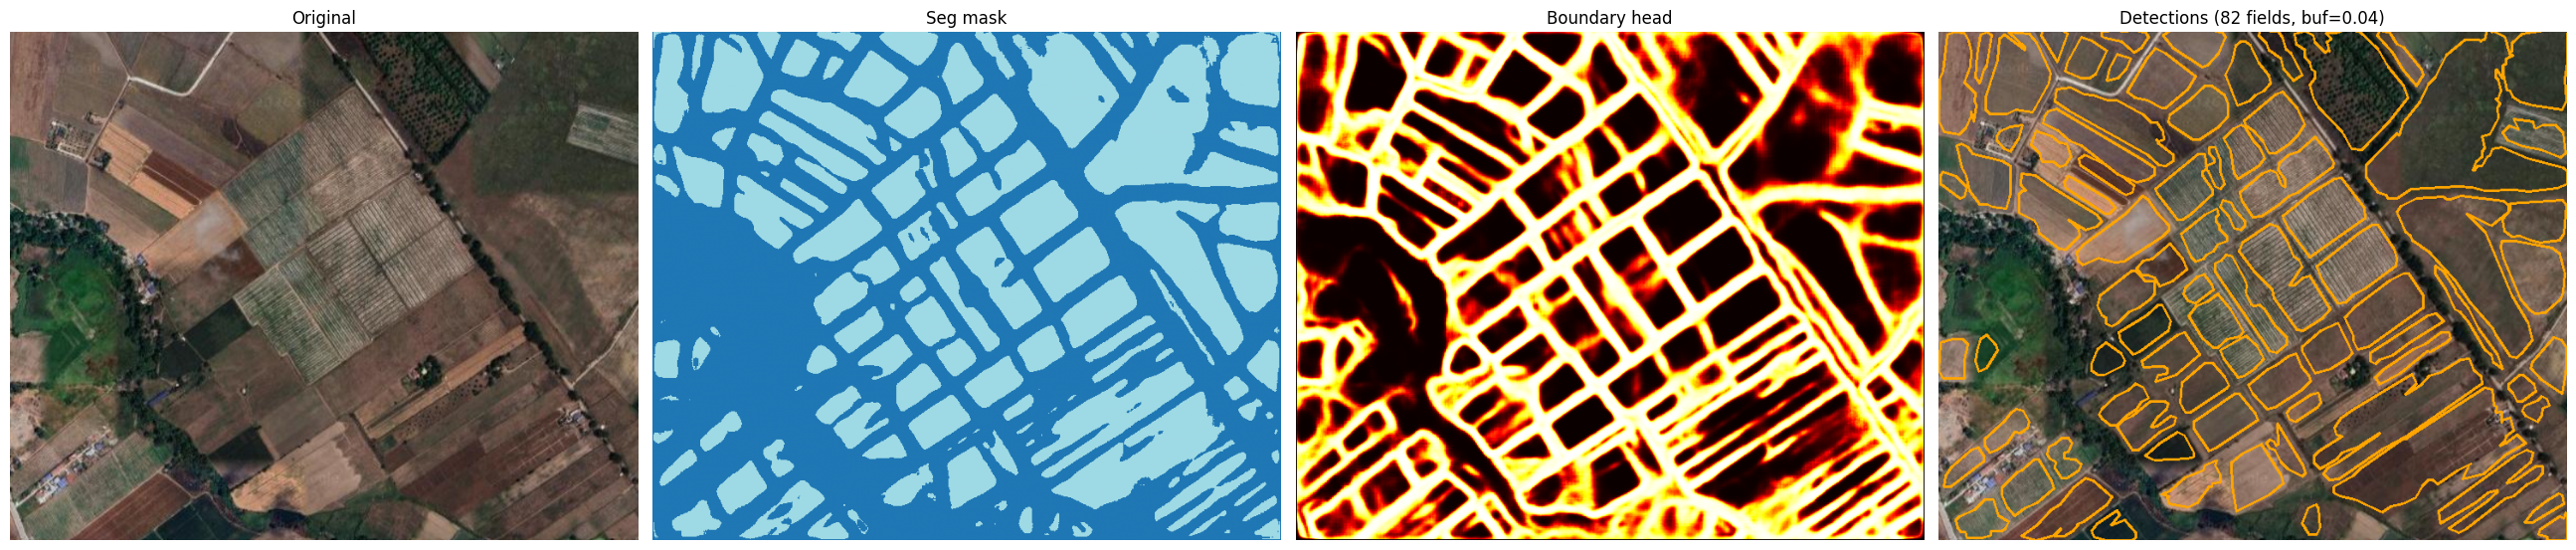


  ── Field statistics ──────────────────────────
  Count          : 82
  Area px  min   : 441
  Area px  mean  : 2,804
  Area px  max   : 21,365
  Buffer   min   : 2.00 px
  Buffer   mean  : 2.21 px
  Buffer   max   : 5.20 px
  ──────────────────────────────────────────────

  ✓ Done in 145.5s  |  82 fields detected



In [16]:
IMAGE_PATH = '/content/drive/MyDrive/AGRI/CropField_Segmentation/Screenshot 2026-04-20 203251.png'

gdf, polys = run_inference(IMAGE_PATH, model, CONFIG)